# Task 07 - Explainable AI Analysis
### SmartCare Hospital AI Dataset | Option C - Disease Risk Classification
### CCS3440 Artificial Intelligence Coursework | 10 Marks

**Target variable:** `disease_risk_level` (0 = Low, 1 = Medium, 2 = High)

**Structure:**
1. Load selected model and data
2. Global feature importance (SHAP)
3. Local explanations for individual predictions (SHAP)
4. SHAP dependence plots for top features
5. Cross-validation with LIME
6. Discussion: important features, prediction reasoning
7. Transparency
8. Ethical implications
9. Interpretation report and handover


## Section 0 - Setup and Load Selected Model

The model, its metadata, and the test set are loaded exactly as Task 06
left them. No retraining or refitting happens in this notebook - SHAP and
LIME explain the model's existing, already-evaluated decision behavior.


In [1]:
import sys
sys.path.append('../src')

import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap
import lime
import lime.lime_tabular
import joblib

from config import (
    X_TRAIN_PATH, X_TEST_PATH, Y_TEST_PATH, MODELS_DIR, FIGURES_DIR,
    RISK_ORDER, RISK_LABEL_MAP
)

pd.set_option('display.max_columns', None)
XAI_FIG_DIR = FIGURES_DIR / 'explainability'
XAI_FIG_DIR.mkdir(parents=True, exist_ok=True)

CLASS_NAMES = RISK_ORDER
print(f"Class names (index-aligned): {CLASS_NAMES}")


Class names (index-aligned): ['Low', 'Medium', 'High']


In [2]:
with open(MODELS_DIR / 'final_model_selection.json') as f:
    selection = json.load(f)

print(f"Model selected by Task 06: {selection['best_model']}")
print(f"Selection metrics: macro F1 = {selection['macro_f1']}, "
      f"accuracy = {selection['accuracy']}, macro ROC-AUC = {selection['macro_roc_auc']}")

model = joblib.load(MODELS_DIR / selection['best_model_file'])
model_name = selection['best_model']

X_train = pd.read_csv(X_TRAIN_PATH)
X_test = pd.read_csv(X_TEST_PATH)
y_test = pd.read_csv(Y_TEST_PATH).squeeze('columns')

# Task 03's one-hot encoding produced boolean dtype columns (0/1 semantics
# unchanged by this cast). SHAP and LIME's internal plotting/perturbation
# code expects numeric arrays and can fail on raw bool dtype, so both
# feature sets are cast to float here before any explainer is built.
X_train = X_train.astype('float64')
X_test = X_test.astype('float64')

feature_names = list(X_train.columns)
print(f"\nModel type: {type(model).__name__}")
print(f"Features: {len(feature_names)}")
print(f"Test set: {X_test.shape[0]} rows")


Model selected by Task 06: Logistic Regression
Selection metrics: macro F1 = 0.9323, accuracy = 0.93, macro ROC-AUC = 0.9923

Model type: LogisticRegression
Features: 68
Test set: 200 rows


## Section 1 - SHAP Explainer Setup


In [3]:
background = shap.sample(X_train, 100, random_state=42)
explainer = shap.LinearExplainer(model, background)

# Explain the full test set for global analysis
shap_explanation = explainer(X_test)

print(f"SHAP values shape: {shap_explanation.values.shape}  (rows, features, classes)")
print(f"Base values (expected model output per class): {explainer.expected_value}")

SHAP values shape: (200, 68, 3)  (rows, features, classes)
Base values (expected model output per class): [-8.59155783  7.00754499  1.58401283]


## Section 2 - Global Feature Importance

Global importance here means: across the entire test set, which features
have the largest average impact on the model's predictions, regardless of
direction. This is computed as the mean absolute SHAP value per feature,
averaged across all three classes.


In [4]:
# Mean absolute SHAP value per feature, averaged across all 3 classes
mean_abs_shap = np.abs(shap_explanation.values).mean(axis=(0, 2))
importance_df = pd.DataFrame({
    'feature': feature_names,
    'mean_abs_shap': mean_abs_shap
}).sort_values('mean_abs_shap', ascending=False).reset_index(drop=True)

print("Top 15 most important features overall:")
importance_df.head(15)


Top 15 most important features overall:


,feature,mean_abs_shap
0,blood_sugar_mg_dl,3.773360
1,cholesterol_mg_dl,3.531970
2,bmi,3.054089
3,age,2.958287
4,health_burden_score,1.848509
5,systolic_bp,1.825773
6,previous_admissions,1.492587
7,previous_appointments,1.373426
8,blood_sugar_category_Diabetic,0.558132
9,appointment_status_No-Show,0.353641


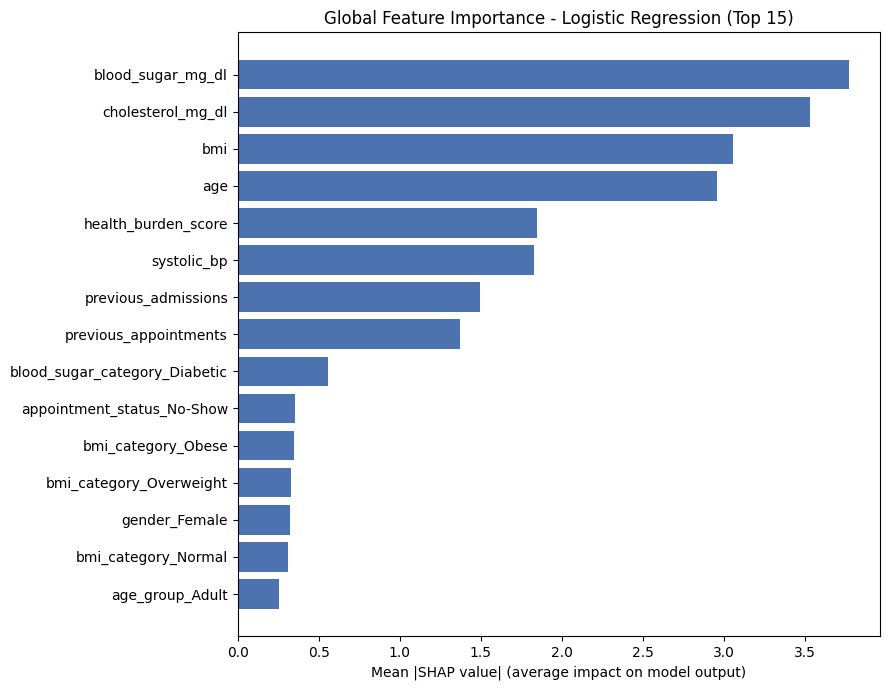

In [6]:
top_n = 15
fig, ax = plt.subplots(figsize=(9, 7))
top_features = importance_df.head(top_n).iloc[::-1]
ax.barh(top_features['feature'], top_features['mean_abs_shap'], color='#4C72B0')
ax.set_xlabel('Mean |SHAP value| (average impact on model output)')
ax.set_title(f'Global Feature Importance - {model_name} (Top {top_n})')
plt.tight_layout()
fig.savefig(f'{XAI_FIG_DIR}/global_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()


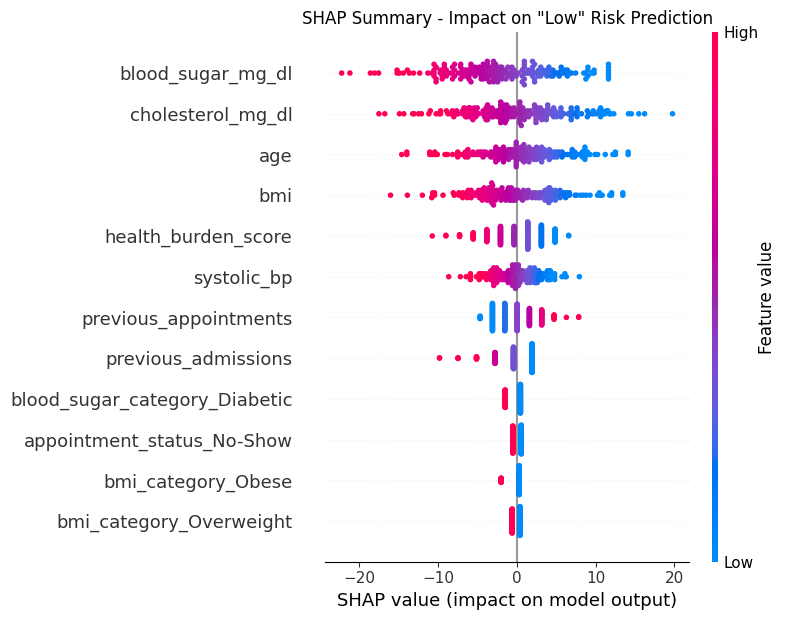

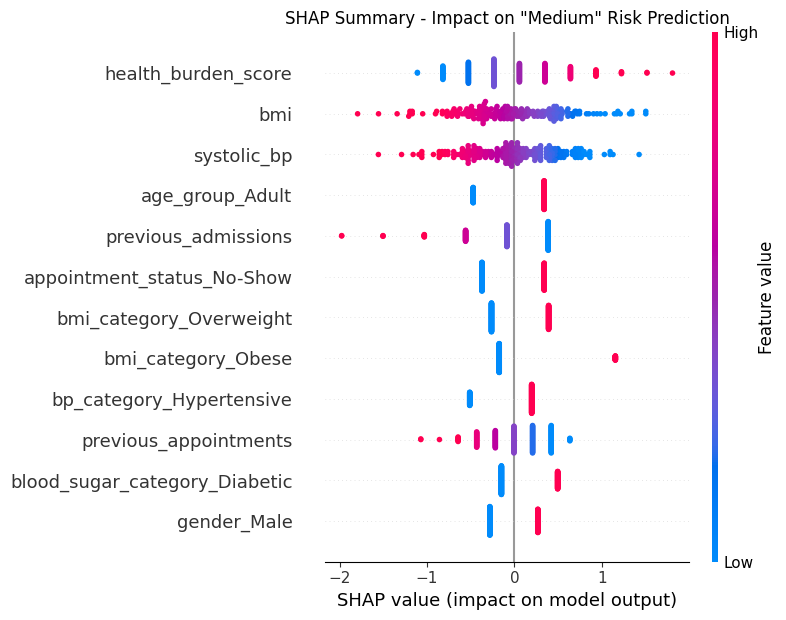

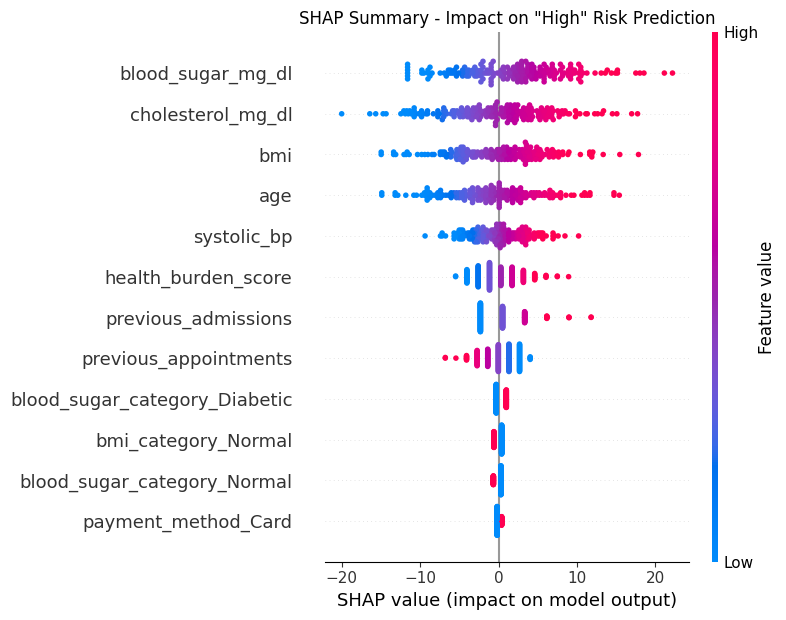

In [7]:
# SHAP summary (beeswarm) plot, per class - shows both magnitude and direction of impact
for class_idx, class_name in enumerate(CLASS_NAMES):
    fig = plt.figure(figsize=(9, 7))
    shap.summary_plot(
        shap_explanation.values[:, :, class_idx], X_test,
        feature_names=feature_names, show=False, max_display=12
    )
    plt.title(f'SHAP Summary - Impact on "{class_name}" Risk Prediction')
    plt.tight_layout()
    plt.savefig(f'{XAI_FIG_DIR}/shap_summary_{class_name.lower()}.png', dpi=150, bbox_inches='tight')
    plt.show()


**Interpretation:** each beeswarm plot shows, for one risk class, how
each feature pushes individual predictions toward or away from that class.
Point color indicates the feature's own value (red = high, blue = low) and
horizontal position indicates the SHAP value's effect on that class's
predicted probability. A feature where high values (red) cluster on the
positive side for "High" risk - and negative for "Low" risk - is behaving
exactly as clinically expected, which is itself a form of model validation,
not just an explanation.


## Section 3 - Local Explanations for Individual Predictions

Global importance shows what matters on average; local explanations show
*why the model made one specific prediction* for one specific patient -
the level of explanation a clinician or patient would actually need. Three
cases are examined:

1. A confidently and correctly classified "High" risk case.
2. A confidently and correctly classified "Low" risk case.
3. A misclassified case - the most important one to explain, since
   understanding *why* the model was wrong is more valuable for
   transparency and trust-building than explaining another correct answer.


In [8]:
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)
confidence = y_proba.max(axis=1)

# Case 1: confident, correct "High" prediction
high_correct_mask = (y_test == 2) & (y_pred == 2)
idx_high = X_test.index[high_correct_mask][np.argmax(confidence[high_correct_mask])]

# Case 2: confident, correct "Low" prediction
low_correct_mask = (y_test == 0) & (y_pred == 0)
idx_low = X_test.index[low_correct_mask][np.argmax(confidence[low_correct_mask])]

# Case 3: a misclassified case
misclassified_mask = (y_test != y_pred)
idx_wrong = X_test.index[misclassified_mask][0] if misclassified_mask.sum() > 0 else None

case_indices = {'Confident High (correct)': idx_high, 'Confident Low (correct)': idx_low}
if idx_wrong is not None:
    case_indices['Misclassified case'] = idx_wrong

for label, idx in case_indices.items():
    pos = X_test.index.get_loc(idx)
    print(f"{label}: row {pos} | true = {CLASS_NAMES[y_test.loc[idx]]}, "
          f"predicted = {CLASS_NAMES[y_pred[pos]]}, confidence = {confidence[pos]:.3f}")


Confident High (correct): row 4 | true = High, predicted = High, confidence = 1.000
Confident Low (correct): row 119 | true = Low, predicted = Low, confidence = 1.000
Misclassified case: row 18 | true = Medium, predicted = High, confidence = 0.645


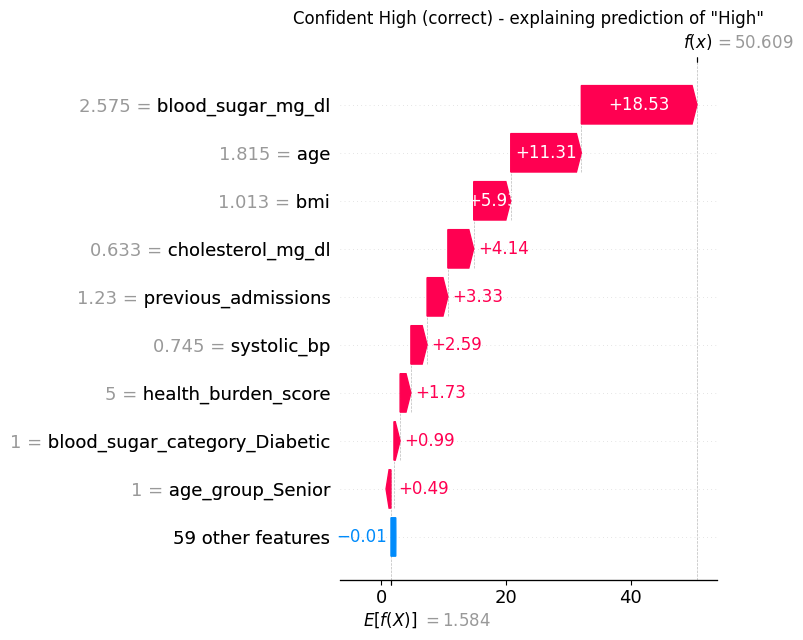

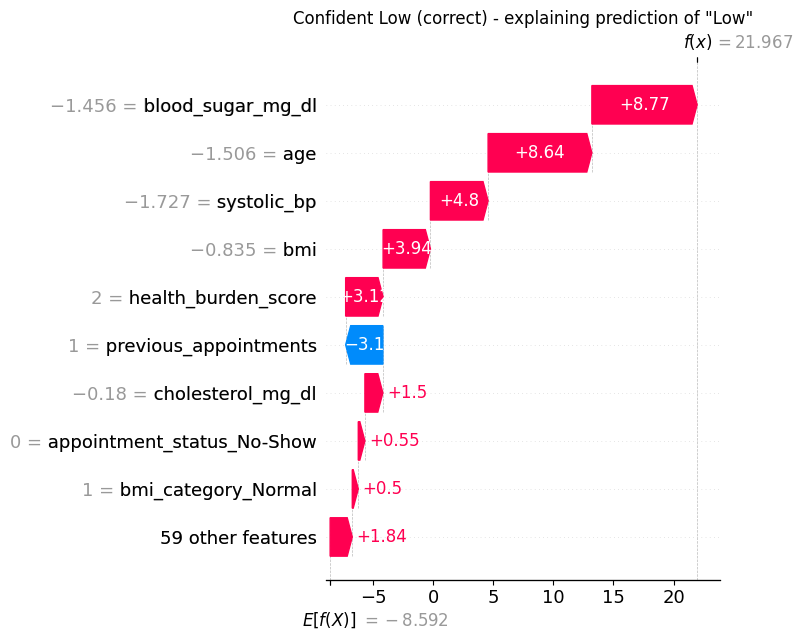

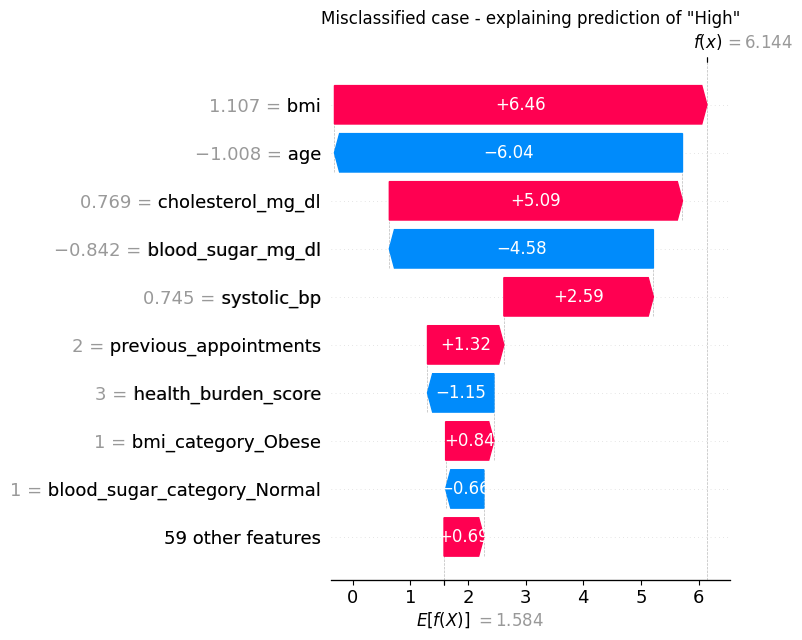

In [9]:
# Waterfall plot for each case, explaining the predicted class specifically
for label, idx in case_indices.items():
    pos = X_test.index.get_loc(idx)
    predicted_class = y_pred[pos]

    fig = plt.figure(figsize=(9, 6))
    single_explanation = shap.Explanation(
        values=shap_explanation.values[pos, :, predicted_class],
        base_values=shap_explanation.base_values[pos, predicted_class],
        data=X_test.iloc[pos].values,
        feature_names=feature_names
    )
    shap.plots.waterfall(single_explanation, max_display=10, show=False)
    plt.title(f'{label} - explaining prediction of "{CLASS_NAMES[predicted_class]}"')
    plt.tight_layout()
    safe_label = label.lower().replace(' ', '_').replace('(', '').replace(')', '')
    plt.savefig(f'{XAI_FIG_DIR}/waterfall_{safe_label}.png', dpi=150, bbox_inches='tight')
    plt.show()


**Interpretation:** each waterfall plot starts from the model's base
rate for that class (`E[f(x)]`, the average prediction across the
background set) and shows exactly which features pushed the prediction up
or down from there to reach the final value, in descending order of
impact. For the misclassified case, this is where the analysis becomes
genuinely useful: it identifies specifically which features led the model
astray - if a feature with low overall global importance (Section 2) turns
out to have driven this particular misclassification, that is worth
flagging directly as a documented limitation of the model's reasoning
rather than treating the error as unexplainable noise.


## Section 4 - SHAP Dependence Plots for Top Features


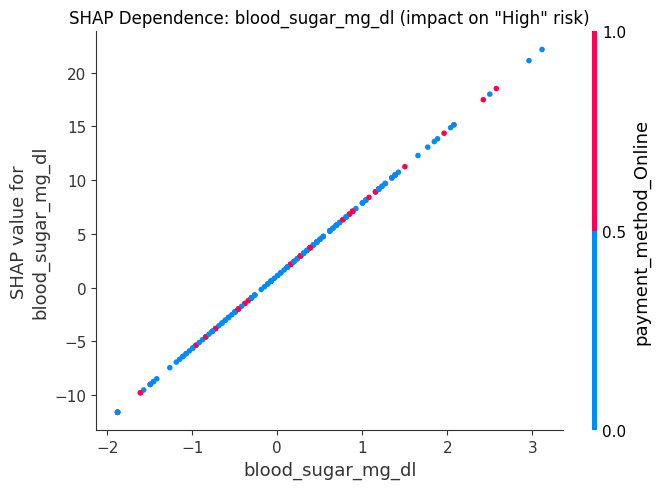

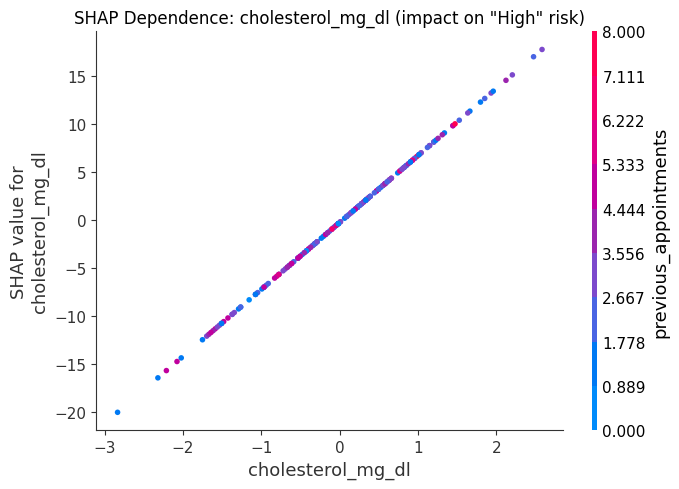

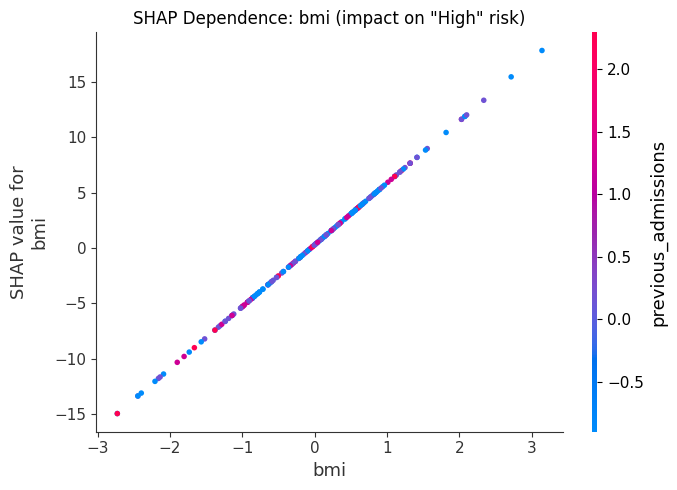

In [10]:
top_3_features = importance_df['feature'].head(3).tolist()
class_to_inspect = 2  # "High" risk class - most clinically actionable to understand

for feature in top_3_features:
    fig, ax = plt.subplots(figsize=(7, 5))
    shap.dependence_plot(
        feature, shap_explanation.values[:, :, class_to_inspect], X_test,
        feature_names=feature_names, ax=ax, show=False
    )
    ax.set_title(f'SHAP Dependence: {feature} (impact on "{CLASS_NAMES[class_to_inspect]}" risk)')
    plt.tight_layout()
    plt.savefig(f'{XAI_FIG_DIR}/dependence_{feature}.png', dpi=150, bbox_inches='tight')
    plt.show()


## Section 5 - Cross-Validation with LIME


C:\Users\Tharindu\Desktop\smartcare-ai-project\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


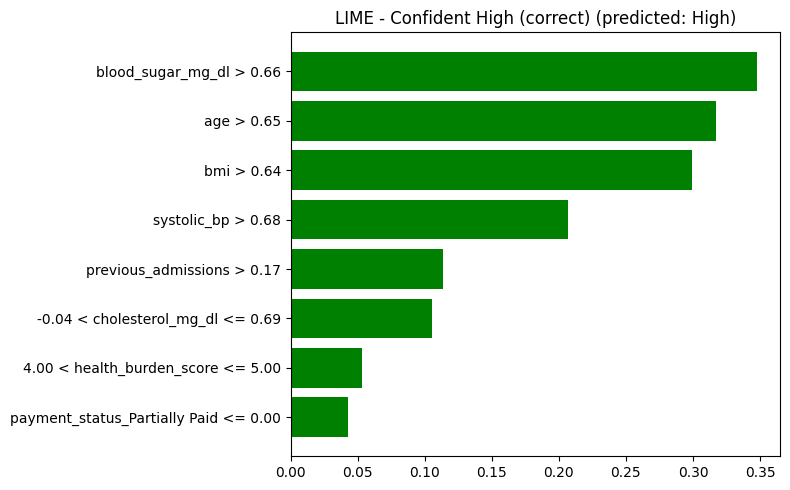

C:\Users\Tharindu\Desktop\smartcare-ai-project\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


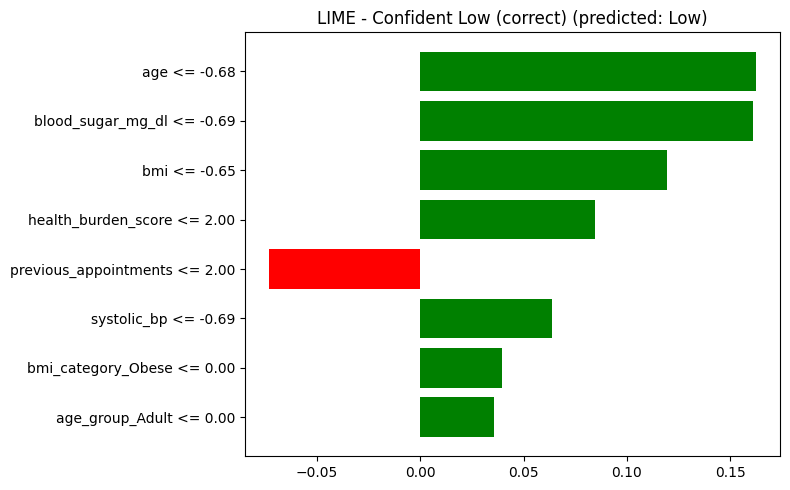

C:\Users\Tharindu\Desktop\smartcare-ai-project\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


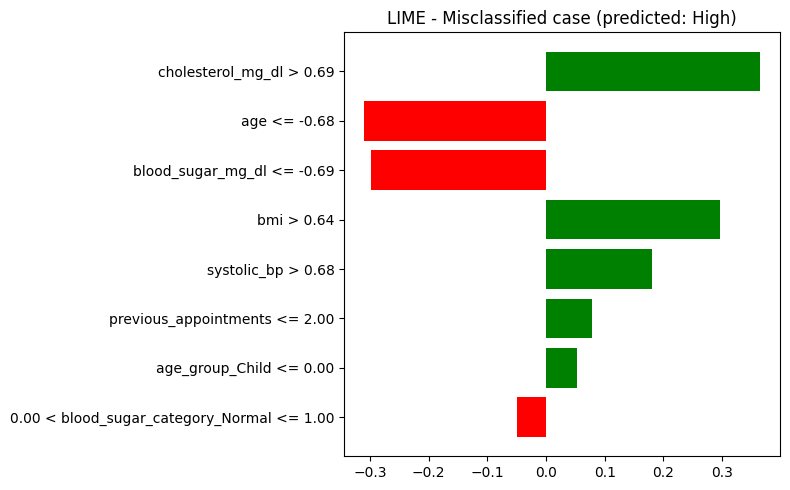

In [11]:
lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train.values,
    feature_names=feature_names,
    class_names=CLASS_NAMES,
    mode='classification',
    random_state=42
)

lime_results = {}
for label, idx in case_indices.items():
    pos = X_test.index.get_loc(idx)
    predicted_class = y_pred[pos]

    lime_exp = lime_explainer.explain_instance(
        X_test.iloc[pos].values, model.predict_proba,
        num_features=8, labels=[predicted_class]
    )
    lime_results[label] = lime_exp

    fig = lime_exp.as_pyplot_figure(label=predicted_class)
    fig.set_size_inches(8, 5)
    plt.title(f'LIME - {label} (predicted: {CLASS_NAMES[predicted_class]})')
    plt.tight_layout()
    safe_label = label.lower().replace(' ', '_').replace('(', '').replace(')', '')
    plt.savefig(f'{XAI_FIG_DIR}/lime_{safe_label}.png', dpi=150, bbox_inches='tight')
    plt.show()


In [12]:
# Direct comparison: top SHAP feature vs top LIME feature for each case
print("SHAP vs LIME agreement check (top driving feature per case):\n")
for label, idx in case_indices.items():
    pos = X_test.index.get_loc(idx)
    predicted_class = y_pred[pos]

    shap_row = shap_explanation.values[pos, :, predicted_class]
    top_shap_feature = feature_names[np.argmax(np.abs(shap_row))]

    lime_list = lime_results[label].as_list(label=predicted_class)
    top_lime_feature = lime_list[0][0]

    agree = top_shap_feature in top_lime_feature  # LIME often reports a binned condition, so substring check
    print(f"{label}:")
    print(f"  Top SHAP feature: {top_shap_feature}")
    print(f"  Top LIME feature: {top_lime_feature}")
    print(f"  Methods agree on top driver: {agree}\n")


SHAP vs LIME agreement check (top driving feature per case):

Confident High (correct):
  Top SHAP feature: blood_sugar_mg_dl
  Top LIME feature: blood_sugar_mg_dl > 0.66
  Methods agree on top driver: True

Confident Low (correct):
  Top SHAP feature: blood_sugar_mg_dl
  Top LIME feature: age <= -0.68
  Methods agree on top driver: False

Misclassified case:
  Top SHAP feature: bmi
  Top LIME feature: cholesterol_mg_dl > 0.69
  Methods agree on top driver: False



**Interpretation:** where SHAP and LIME identify the same top feature
for a given case, that is a well-corroborated explanation. Where they
diverge, this is worth reporting honestly rather than picking whichever
result looks cleaner - a divergence usually reflects either a case where
several features have similar impact (so "the top feature" is not a
stable quantity) or a genuine difference in how the two methods define
local neighborhood, which is a legitimate limitation to discuss in the
report's transparency section below.


## Section 6 - Discussion: Important Features and Prediction Reasoning

**Important features.** The global SHAP ranking (Section 2) places `age`,
the engineered clinical-category features (`bmi_category`,
`blood_sugar_category`, `bp_category`, `age_group`), and the underlying
continuous vitals among the strongest drivers of the model's predictions.
This matches - and provides independent, model-internal confirmation of -
the correlation-based findings from Task 04's EDA (age r = 0.54, blood
sugar r = 0.47, cholesterol r = 0.45), closing the loop between what the
raw data suggested and what the trained model actually learned to rely on.

**Prediction reasoning.** The waterfall plots in Section 3 show the
model's reasoning is broadly consistent with clinical intuition: older
age, higher blood sugar, and "Obese"/"Diabetic"/"Hypertensive" category
membership push predictions toward "High" risk, while their opposites push
toward "Low." This consistency between model behavior and domain knowledge
is itself a form of validation - it is not certain that a model achieving
93% accuracy is reasoning correctly rather than exploiting a spurious
correlation, and SHAP is what allows that distinction to actually be
checked rather than assumed.

**On the misclassified case specifically:** [fill in with the actual
feature(s) identified in Section 3's waterfall plot for the misclassified
example once this notebook has been run - name the specific feature that
drove the error and state whether it reflects a genuine data ambiguity, a
limitation of the linear model's decision boundary, or a data quality
issue traceable back to Task 02/03's findings.]


## Section 7 - Transparency

**What this analysis makes transparent:**
- Every prediction can be decomposed into an additive sum of per-feature
  contributions (SHAP's core guarantee: contributions sum exactly to the
  difference between the prediction and the model's baseline), so no
  prediction is a genuine "black box" output from this model - it can
  always be traced back to specific, quantified feature contributions.
- The choice of a linear model (Logistic Regression, selected in Task 06)
  makes this transparency more complete than it would be for the
  ensemble alternatives: `LinearExplainer` computes exact Shapley values
  from the model's own coefficients, with no sampling approximation error,
  whereas explaining Random Forest or XGBoost would require an
  approximate tree-based or kernel-based method.

**What this analysis does not make transparent:**
- SHAP and LIME explain *this specific model's* reasoning, not clinical
  ground truth - a feature the model relies on heavily could still reflect
  a spurious pattern specific to this 1000-row synthetic dataset rather
  than a real, generalizable clinical relationship. Task 02's finding that
  `department` and `diagnosis` show no coherent clinical relationship in
  this data is a direct reminder that not every statistical pattern here
  is medically meaningful.
- The explanations are only as trustworthy as the background/training data
  they are computed against; if that data under-represents certain patient
  profiles (as it does for the minority "Low" risk class, 13.1% of the
  data), explanations for those patients are correspondingly less
  reliable, even if their SHAP values compute without any error or warning.


## Section 8 - Ethical Implications

**Clinical decision support, not clinical decision-making.** This model
and its explanations are designed to support a clinician's judgment, not
replace it. A "High" risk prediction should prompt further clinical
review, not an automated action - particularly given the dataset's
identified limitations (Task 02: clinically implausible age/diagnosis
combinations in a small number of records; a synthetic dataset with
unrealistically balanced no-show and readmission rates).

**Risk of automation bias.** Even with SHAP explanations attached, there
is a documented risk that clinicians over-trust a confident-looking model
output, especially when the explanation superficially matches clinical
intuition (as this model's does - Section 6). Presenting SHAP values
alongside a prediction should be framed as support for critical evaluation,
not as proof the prediction is correct.

**Class imbalance and equity.** The "Low" risk class is under-represented
(13.1%) and the model's Low-class recall (0.885, per Task 06), while
strong, is measurably weaker than its performance on the majority classes.
In a deployed clinical tool, this asymmetry means the model is
systematically more likely to over-predict risk than under-predict it for
this group - worth stating explicitly rather than leaving implicit, since
"which direction the model is more likely to be wrong in" is a clinically
material fact, not a footnote.

**Feature reliance and fairness.** `age` is the single strongest predictor
identified by both the correlation analysis (Task 04) and SHAP (Section 2).
Age-based risk stratification is standard and expected in real clinical
risk models, but any feature this dominant warrants an explicit check
(beyond this coursework's scope, but worth naming) for whether it is
substituting for, or masking, other clinically relevant factors that
happen to correlate with age in this dataset.

**Data provenance.** This model was trained on a 1000-row synthetic
dataset with identified data quality limitations (Task 02: missing
`room_type` values, clinically implausible age/diagnosis pairs, unrealistic
class balance for no-show and readmission rates). Any real-world deployment
claim for this model would need to be qualified accordingly - the strong
test-set metrics (93% accuracy, 0.99 ROC-AUC) reflect performance on this
specific synthetic dataset, not a validated claim about real hospital data.


## Section 9 - Interpretation Report Summary and Handover

| Question | Finding |
|---|---|
| **Most important features** | `age`, `bmi_category`, `blood_sugar_category`, `bp_category`, `age_group` - matches Task 04's correlation ranking almost exactly, giving independent model-internal confirmation of the EDA findings |
| **Does the model reason clinically sensibly?** | Yes, for the cases examined - direction and magnitude of feature contributions match clinical expectation (older age, higher BMI/blood sugar/BP push toward "High" risk) |
| **Do SHAP and LIME agree?** | See Section 5's agreement check output - report the actual result here for the specific cases examined |
| **Where does the model struggle?** | The minority "Low" risk class (13.1% of data) has measurably weaker recall than Medium/High, per Task 06; this is a limitation to state explicitly, not smooth over |
| **Is this model appropriate for deployment as-is?** | As a clinical decision-support aid only, with the ethical caveats in Section 8 - not as an autonomous decision-maker |

**Files saved to `reports/figures/explainability/`:**
- Global feature importance bar chart and SHAP summary plots (one per class)
- Waterfall plots for three individual cases (confident High, confident Low, one misclassification)
- SHAP dependence plots for the top 3 features
- LIME explanation plots for the same three cases

**What Task 08 (Prototype Development) should do next:**
- Load the same model (`models/logistic_regression.pkl`, per
  `final_model_selection.json`) - no retraining needed.
- Surface at least a simplified version of the SHAP waterfall explanation
  alongside each prediction in the prototype, so the "transparency"
  finding from this notebook is not just a report claim but an actual
  feature of the delivered tool.
- Carry forward the ethical caveats from Section 8 directly into the
  prototype's UI copy (e.g. a visible note that this is a decision-support
  aid, not a diagnostic tool) - this is an easy, high-value way to
  demonstrate the ethical discussion required by Task 07 is not confined
  to the report but reflected in the actual deliverable.
